In [1]:
import os
import warnings

In [2]:
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import torch
import shap
import numpy as np
import pandas as pd
from transformers import pipeline
from IPython.display import display, HTML

In [4]:
model_paths = {
    "MuRIL": r"D:\Major Project\SpamX\machine_learning\models\MuRIL\final_muril_calibrated1",
    "XLMR": r"D:\Major Project\SpamX\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1"
}

In [5]:
def analyze_and_explain(test_text, model_key):
    path = model_paths[model_key]
    
    pipe = pipeline(
        "text-classification", 
        model=path, 
        tokenizer=path, 
        device=0 if torch.cuda.is_available() else -1,
        top_k=None 
    )
    
    explainer = shap.Explainer(pipe)
    shap_result = explainer([test_text])
    
    raw_pred = pipe(test_text)[0]
    best_pred = max(raw_pred, key=lambda x: x['score'])
    pred_label = "SPAM" if best_pred['label'] == 'LABEL_1' else "HAM"
    label_color = "#d9534f" if pred_label == "SPAM" else "#00a81c"
    
    raw_tokens = shap_result.feature_names[0]
    raw_values = shap_result.values[0, :, 1]

    impact_html = ""
    for t, v in zip(raw_tokens, raw_values):
        t_clean = t.replace('Ġ', '').replace(' ', '').replace('##', '')
        if t_clean.strip() and t not in ['<s>', '</s>', '<pad>', '[CLS]', '[SEP]']:
            alpha = min(abs(v) * 2.5, 0.9)
            bg = f"rgba(217, 83, 79, {alpha})" if v > 0 else f"rgba(2, 117, 216, {alpha})"
            txt_color = "white" if alpha > 0.4 else "black"
            
            impact_html += f'''
                <div style="display:inline-block; margin:3px; padding:5px 10px; border-radius:8px; 
                            background-color:{bg}; color:{txt_color}; border:1px solid #ddd; font-weight:500;">
                    {t_clean} <br>
                    <span style="font-size:0.7em; opacity:0.8;">{"+" if v>0 else ""}{v:.2f}</span>
                </div>'''

    ui_html = f"""
    <div style="border: 4px solid {label_color}; padding: 25px; border-radius: 20px; background-color: #ffffff; 
                font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.1);">
        <div style="display: flex; justify-content: space-between; align-items: center;">
            <h2 style="color: {label_color}; margin: 0; letter-spacing: 1px;">SpamX: {model_key}</h2>
            <div style="background-color: {label_color}; color: white; padding: 10px 25px; border-radius: 50px; 
                        font-weight: bold; font-size: 1.2em; box-shadow: 0 2px 5px rgba(0,0,0,0.2);">
                {pred_label}
            </div>
        </div>
        <p style="margin: 20px 0; font-size: 1.1em; line-height: 1.5; color: #333;">
            <b>Input Content:</b> <i style="color: #666;">"{test_text}"</i>
        </p>
        <div style="background: #f8f9fa; padding: 10px; border-radius: 10px; display: inline-block;">
            <b>Model Confidence:</b> <span style="color: {label_color}; font-size: 1.1em;">{best_pred['score']*100:.2f}%</span>
        </div>
        <hr style="border: 0.5px solid #eee; margin: 20px 0;">
        <h4 style="margin-bottom: 10px; color: #555;">Word Impact Context (SHAP Attribution)</h4>
        <div style="line-height: 2.5;">
            {impact_html}
        </div>
        <div style="margin-top: 15px; font-size: 0.85em; color: #999;">
            * Red intensity indicates spam trigger strength. Blue indicates legitimate context.
        </div>
    </div>
    """
    display(HTML(ui_html))

In [6]:
comment = "Your content is great, but did you check the crypto analyst on my page? He is making everyone rich!"
analyze_and_explain(comment, "MuRIL")
analyze_and_explain(comment, "XLMR")

WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.5.1+cu121)
    Python  3.10.11 (you have 3.10.11)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\jeeve\AppData\Local\Programs\Python\Python310\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
  File "c:\Users\jeeve\AppData\Local\Programs\Python\Python310\lib\site-packages\triton\__init__.py", line 8, in <module>
    from .runtime import (
  File "c:\Users\jeeve\AppData\Local\Programs\Python\Python310\lib\site-packages\triton\runtime\__init__.py", line 1, in <module>
    from .autotuner import (Autotuner, Con

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.12s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

XLM RoBERTa

In [20]:
import torch
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from transformers import pipeline
from IPython.display import display, HTML

In [21]:
model_path = r"D:\Major Project\SpamX\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1_v2"
test_text = "Your content is great, but did you check the crypto analyst on my page?"

In [22]:
predict_pipeline = pipeline(
    "text-classification", 
    model=model_path, 
    tokenizer=model_path, 
    device=0 if torch.cuda.is_available() else -1
)

In [23]:
result = predict_pipeline(test_text)[0]
pred_idx = 0 if result['label'] == 'LABEL_0' else 1
label_name = "HAM" if pred_idx == 0 else "SPAM"
label_color = "#00a81c" if label_name == "HAM" else "#d9534f"


In [24]:
explainer = shap.Explainer(predict_pipeline)
shap_result = explainer([test_text])
tokens = [t.replace(' ', '').replace('Ġ', '') for t in shap_result.feature_names[0]]
values = shap_result.values[0, :, pred_idx]
clean_tokens, clean_values = [], []
for t, v in zip(tokens, values):
    if t.strip() and t not in ['<s>', '</s>', '<pad>', '']:
        clean_tokens.append(t)
        clean_values.append(v)

  0%|          | 0/342 [00:00<?, ?it/s]

In [25]:
display(HTML(f"""
<div style="border: 3px solid {label_color}; padding: 20px; border-radius: 15px; background-color: #ffffff; font-family: sans-serif;">
    <h2 style="color: {label_color}; margin: 0; text-transform: uppercase;">XLM RoBERTa</h2>
    <hr style="border: 1px solid #eee;">
    <p style="font-size: 1.2em;"><b>Input Text:</b> <span style="color: #444;">"{test_text}"</span></p>
    <p style="font-size: 1.2em;"><b>Detection:</b> 
        <span style="background-color: {label_color}; color: white; padding: 5px 15px; border-radius: 5px; font-weight: bold;">
            {label_name}
        </span>
    </p>
    <p><b>Model Confidence:</b> {result['score']*100:.2f}%</p>
</div>
"""))

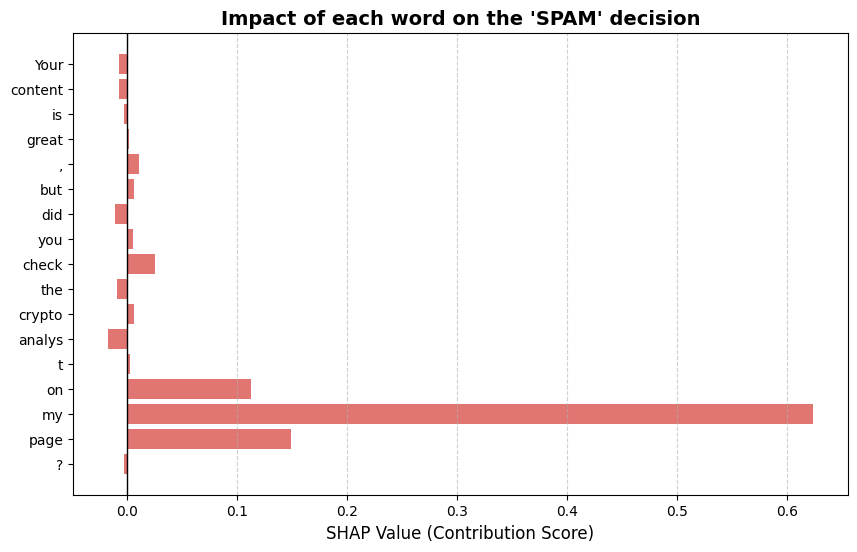

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(clean_tokens, clean_values, color=label_color, alpha=0.8)
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Impact of each word on the '{label_name}' decision", fontsize=14, fontweight='bold')
plt.xlabel("SHAP Value (Contribution Score)", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

MuRIL

In [27]:
model_path = r"D:\Major Project\SpamX\machine_learning\models\MuRIL\final_muril_calibrated1_v2"
test_text = "Your content is great, but did you check the crypto analyst on my page?"

In [28]:
predict_pipeline = pipeline(
    "text-classification", 
    model=model_path, 
    tokenizer=model_path, 
    device=0 if torch.cuda.is_available() else -1
)

In [29]:
result = predict_pipeline(test_text)[0]
pred_idx = 0 if result['label'] == 'LABEL_0' else 1
label_name = "HAM" if pred_idx == 0 else "SPAM"
label_color = "#00a81c" if label_name == "HAM" else "#d9534f"


In [30]:
explainer = shap.Explainer(predict_pipeline)
shap_result = explainer([test_text])
tokens = [t.replace(' ', '').replace('Ġ', '') for t in shap_result.feature_names[0]]
values = shap_result.values[0, :, pred_idx]
clean_tokens, clean_values = [], []
for t, v in zip(tokens, values):
    if t.strip() and t not in ['<s>', '</s>', '<pad>', '']:
        clean_tokens.append(t)
        clean_values.append(v)

  0%|          | 0/342 [00:00<?, ?it/s]

In [31]:
display(HTML(f"""
<div style="border: 3px solid {label_color}; padding: 20px; border-radius: 15px; background-color: #ffffff; font-family: sans-serif;">
    <h2 style="color: {label_color}; margin: 0; text-transform: uppercase;">MuRIL</h2>
    <hr style="border: 1px solid #eee;">
    <p style="font-size: 1.2em;"><b>Input Text:</b> <span style="color: #444;">"{test_text}"</span></p>
    <p style="font-size: 1.2em;"><b>Detection:</b> 
        <span style="background-color: {label_color}; color: white; padding: 5px 15px; border-radius: 5px; font-weight: bold;">
            {label_name}
        </span>
    </p>
    <p><b>Model Confidence:</b> {result['score']*100:.2f}%</p>
</div>
"""))

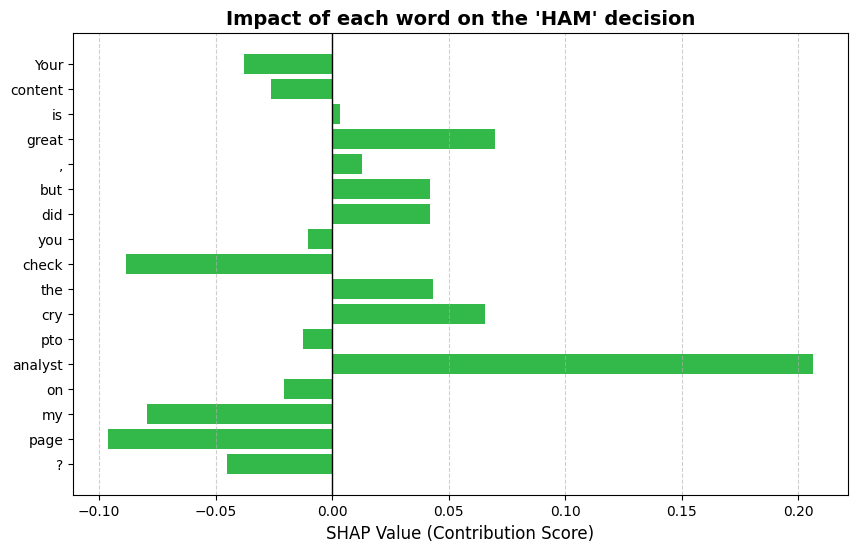

In [32]:
plt.figure(figsize=(10, 6))
plt.barh(clean_tokens, clean_values, color=label_color, alpha=0.8)
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Impact of each word on the '{label_name}' decision", fontsize=14, fontweight='bold')
plt.xlabel("SHAP Value (Contribution Score)", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()